<p>
    <a href="https://umt.edu.al/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2024/11/Universiteti-Metropolitan-Tirana.webp" width="200" alt="UMT Logo">
    </a>
</p>

# Rezolucioni

### Rezolucioni i Imazhit

**Rezolucioni hapësinor**  
- Tregon numrin e pikselëve të dallueshëm në imazh.
- Matet në njësi si **pikselë për inç (dpi)** ose **pikselë për centimetër**.
- **DPI** (dots per inch) tregon numrin e pikselëve për inç në printime.
- Përdoret për të përcaktuar nivelin e detajeve të imazhit.

**Si ta shfrytëzojmë**:
- Rritja e rezolucionit: më shumë detaje, më shumë hapësirë disku.
- Ulja e rezolucionit: kursim hapësire dhe shpejtësi, por humbje detajesh.

---

**Rezolucioni i Intensitetit**  
- Përcakton ndryshimin më të vogël të dallueshëm në intensitetin e ngjyrës.
- Matet me **bit-depth**, si **8 bit**, **12 bit**, **16 bit**, etj.
- Sa më shumë bit, aq më shumë nivele të intensitetit dhe detaje në ngjyra.

**Si ta shfrytëzojmë**:
- Rritja e intensitetit: më shumë detaje dhe gradacione ngjyrash.
- Ulja e intensitetit: kursim hapësire, për përdorim të shpejtë dhe më pak detaje.

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt



In [2]:

# Hapim imazhin
im = ...("lenna.png")


In [5]:

# Ulim rezolucionin hapësinor (dimensiones)
width, height = im.size
new_width, new_height = ...  # ulim gjysmën e dimensioneve


In [8]:

# Reduktojmë imazhin 
im_low_res = im...


In [14]:

# Pjesa e dytë është ulja e intensitetit (konvertimi në një gamë të kufizuar ngjyrash)
im_array = np.array(im)
im_low_intensity = np.clip(im_array // 2, 0, 255)  # ulim intensitetin duke ndarë me 2
im_low_intensity = Image.fromarray(im_low_intensity.astype(np.uint8))


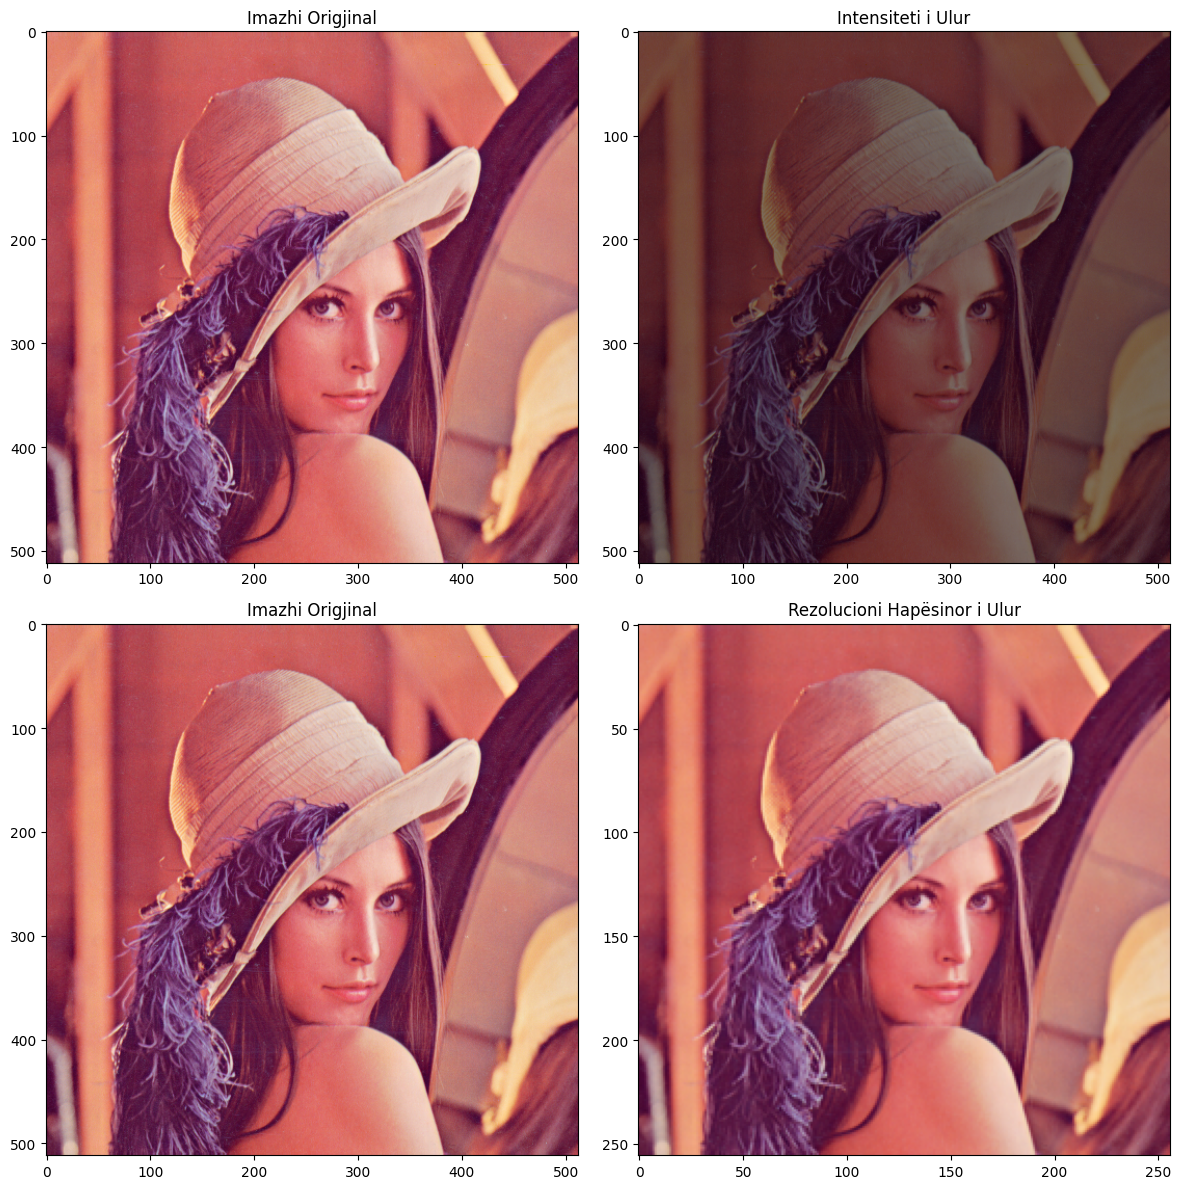

In [15]:

# Krijojmë figura për të shfaqur imazhet
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Shfaqim imazhet me rezolucion të ulur dhe intensitet të ulur
axes[0, 0].imshow(im)
axes[0, 0].set_title('Imazhi Origjinal')
axes[0, 1].imshow(im_low_intensity)
axes[0, 1].set_title('Intensiteti i Ulur')
axes[1, 0].imshow(im)  # Përsëri imazhi i ulur
axes[1, 0].set_title('Imazhi Origjinal')
axes[1, 1].imshow(im_low_res)  # Përsëri imazhi me intensitet të ulur
axes[1, 1].set_title('Rezolucioni Hapësinor i Ulur')

# Heqim etiketat e oshtullave
#for ax in axes.flatten():
    #ax.axis('off')

plt.tight_layout()
plt.show()

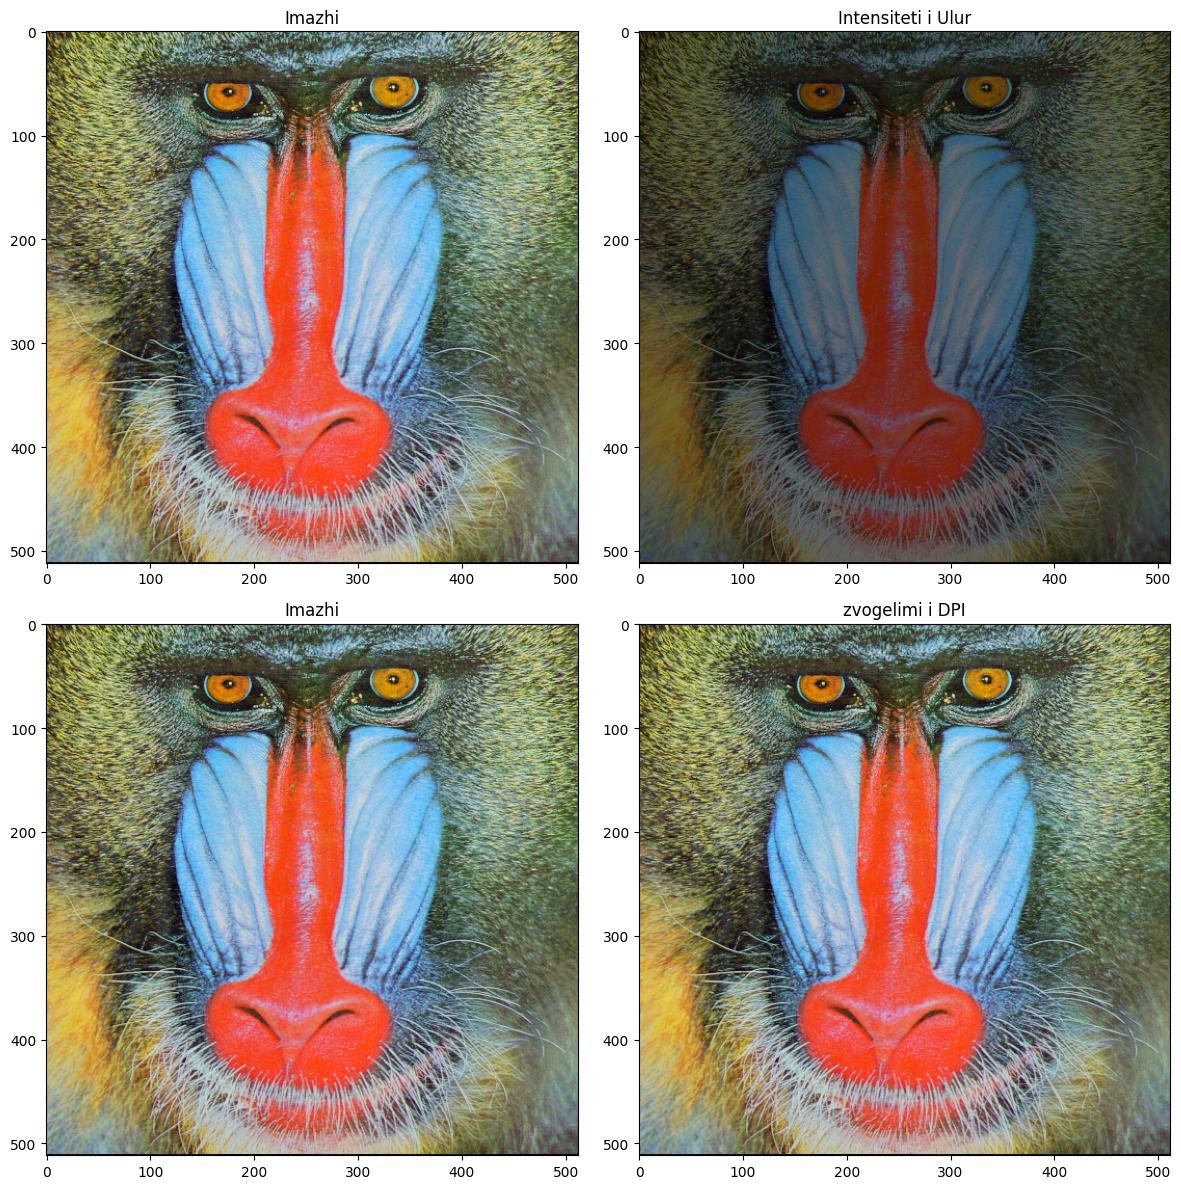

In [17]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Hapim imazhin
im = Image.open("baboon.png")

# Ulim rezolucionin hapësinor duke ndryshuar DPI (dot per inch)
new_dpi = (70, 70)  # Një DPI më i ulët (shembull: 72 DPI)
im_low_dpi = im.copy()
im_low_dpi.info['dpi'] = new_dpi


# Pjesa e dytë është ulja e intensitetit (konvertimi në një gamë të kufizuar ngjyrash)
im_array = np.array(im)
im_low_intensity = np.clip(im_array // 2, 0, 255)  # ulim intensitetin duke ndarë me 2
im_low_intensity = Image.fromarray(im_low_intensity.astype(np.uint8))

# Krijojmë figura për të shfaqur imazhet
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Shfaqim imazhin me rezolucion të ulur (DPI) dhe intensitet të ulur
axes[0, 0].imshow(im)
axes[0, 0].set_title('Imazhi')
axes[0, 1].imshow(im_low_intensity)
axes[0, 1].set_title('Intensiteti i Ulur')
axes[1, 0].imshow(im)  # Përsëri imazhi me DPI të ulur
axes[1, 0].set_title('Imazhi')
axes[1, 1].imshow(im_low_dpi)  # Përsëri imazhi me intensitet të ulur
axes[1, 1].set_title('zvogelimi i DPI')


plt.tight_layout()
plt.show()


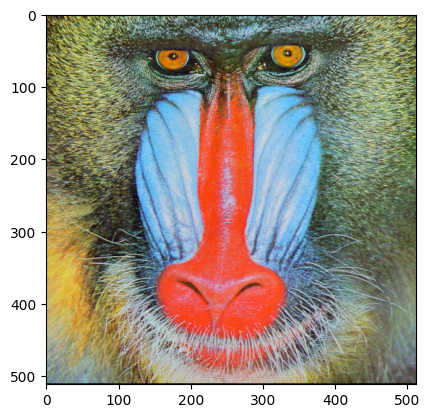

In [21]:
im_low_dpi.save("output.png", dpi=new_dpi)
new_dpi_low = Image.open("output.png")
plt.imshow(new_dpi_low)
plt.show()

In [23]:
print(im.size, new_dpi_low.size)


(512, 512) (512, 512)


In [27]:
print(im.info)

{'dpi': (1199.9976, 1199.9976)}


## Interpolimi

Për të përdorur **Interpolimin e Fqinjit më të Afërt (Nearest Neighbor Interpolation)**, do të duhet të përdorim opsionin `Image.NEAREST` pjes të `im.resize`. Ja një shembull se si mund ta bëni këtë:

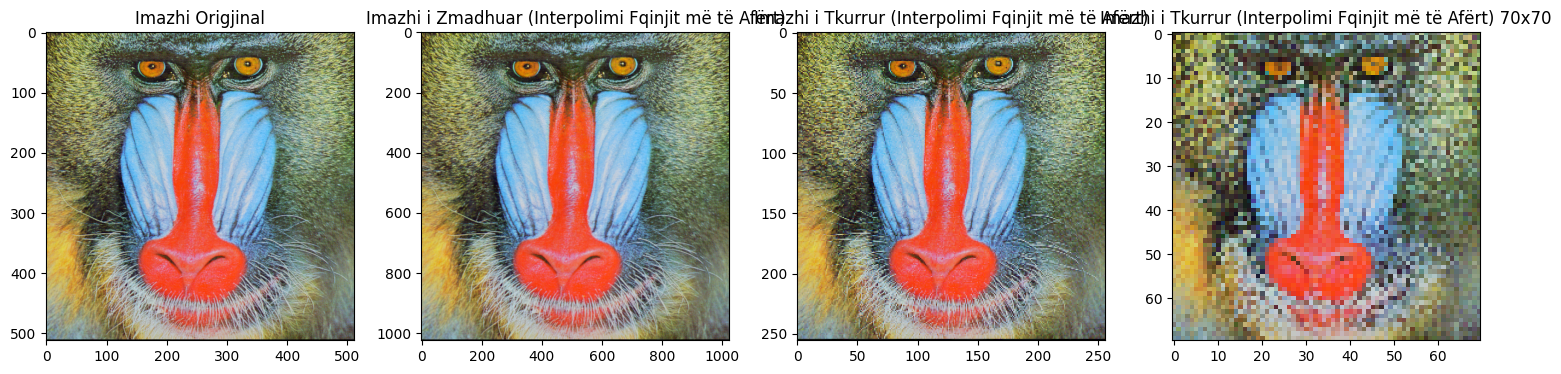

In [29]:

# Zmadhimi i imazhit me interpolim (Fqinjit më të Afërt)
im_resized_up = im.resize((im.width * 2, im.height * 2), Image.NEAREST)

# Tkurrja e imazhit me interpolim (Fqinjit më të Afërt)
im_resized_down = im.resize((im.width // 2, im.height // 2), Image.NEAREST)

# Tkurrja e imazhit me interpolim në 70x70 (Fqinjit më të Afërt)
im_resized_70x70 = im.resize((70, 70), Image.NEAREST)

# Krijojmë figura për të shfaqur imazhet
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Shfaqim imazhin origjinal dhe të zmadhuar dhe të tkurrur
axes[0].imshow(im)
axes[0].set_title('Imazhi Origjinal')

axes[1].imshow(im_resized_up)
axes[1].set_title('Imazhi i Zmadhuar (Interpolimi Fqinjit më të Afërt)')

axes[2].imshow(im_resized_down)
axes[2].set_title('Imazhi i Tkurrur (Interpolimi Fqinjit më të Afërt)')

axes[3].imshow(im_resized_70x70)
axes[3].set_title('Imazhi i Tkurrur (Interpolimi Fqinjit më të Afërt) 70x70')


plt.tight_layout()
plt.show()


**Interpolimi Bilinear** është një metodë tjetër e përdorur për zmadhimin dhe tkurrjen e imazheve, dhe është një përmirësim i metodës së interpolimit të fqinjit më të afërt. Kjo metodë përdor dy drejtime (horizontal dhe vertical) për të përcaktuar vlerën e një pikselli të ri bazuar në katër pikselët më të afërt. Kjo i mundëson që imazhet të jenë më të qarta dhe më të natyrshme se kur përdoret interpolimi i fqinjit më të afërt.

Ja një shembull i përdorimit të **Interpolimit Bilinear** në një imazh për zmadhim dhe tkurrje:

C:\Users\User\AppData\Local\Temp\ipykernel_21028\3111181195.py:2: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  im_resized_up = im.resize((im.width * 2, im.height * 2), Image.BILINEAR)
C:\Users\User\AppData\Local\Temp\ipykernel_21028\3111181195.py:5: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  im_resized_down = im.resize((im.width // 2, im.height // 2), Image.BILINEAR)
C:\Users\User\AppData\Local\Temp\ipykernel_21028\3111181195.py:8: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  im_resized_70x70 = im.resize((70, 70), Image.BILINEAR)


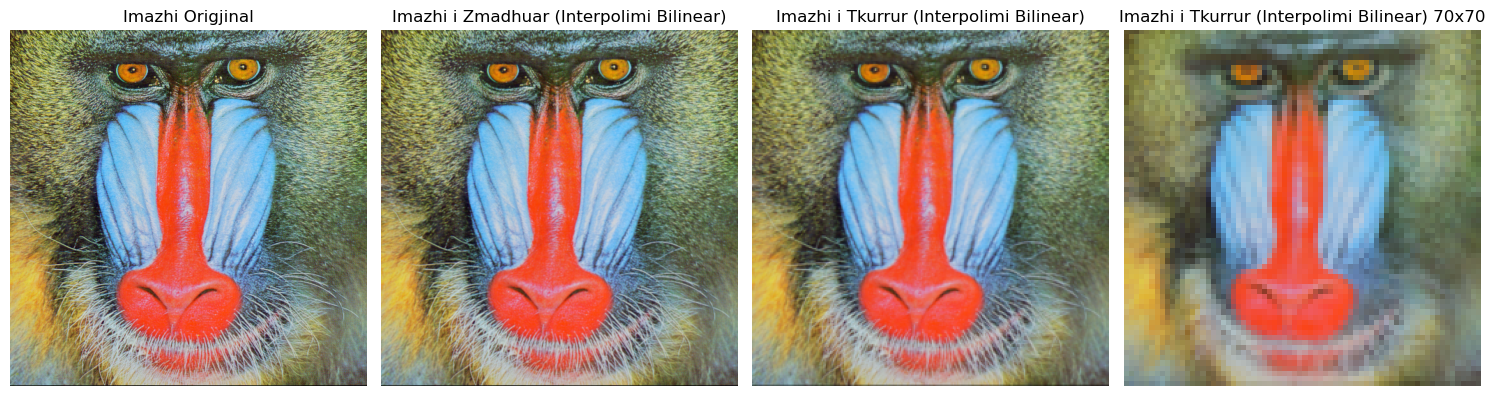

In [14]:

# Zmadhimi i imazhit me interpolim Bilinear
im_resized_up = im.resize((im.width * 2, im.height * 2), Image.BILINEAR)

# Tkurrja e imazhit me interpolim Bilinear
im_resized_down = im.resize((im.width // 2, im.height // 2), Image.BILINEAR)

# Tkurrja e imazhit me interpolim Bilinear në 70x70
im_resized_70x70 = im.resize((70, 70), Image.BILINEAR)

# Krijojmë figura për të shfaqur imazhet
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Shfaqim imazhin origjinal dhe të zmadhuar dhe të tkurrur
axes[0].imshow(im)
axes[0].set_title('Imazhi Origjinal')

axes[1].imshow(im_resized_up)
axes[1].set_title('Imazhi i Zmadhuar (Interpolimi Bilinear)')

axes[2].imshow(im_resized_down)
axes[2].set_title('Imazhi i Tkurrur (Interpolimi Bilinear)')

axes[3].imshow(im_resized_70x70)
axes[3].set_title('Imazhi i Tkurrur (Interpolimi Bilinear) 70x70')

# Heqim etiketat e oshtullave
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


**Image.BICUBIC** është një metodë interpolimi që përdoret për të rritur ose tkurrur imazhet duke përdorur një algoritëm më të avancuar se Interpolimi i Fqinjit më të Afërt. Ky metodë merr parasysh një numër më të madh fqinjësh për të krijuar një vlerë të re për çdo piksel, që rezulton në imazhe më të qarta dhe më të natyrshme kur krahasohet me interpolimin e fqinjit më të afërt.

Nëse përdorni `Image.BICUBIC`, procesi i interpolimit është më i saktë dhe më i natyrshëm për imazhet e zmadhuara ose të tkurrura. Ky metodë përdor një funksion kubik për të përcaktuar vlerat e pikseleve të reja.

C:\Users\User\AppData\Local\Temp\ipykernel_21028\2310667029.py:2: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  im_resized_up = im.resize((im.width * 2, im.height * 2), Image.BICUBIC)
C:\Users\User\AppData\Local\Temp\ipykernel_21028\2310667029.py:5: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  im_resized_down = im.resize((im.width // 2, im.height // 2), Image.BICUBIC)
C:\Users\User\AppData\Local\Temp\ipykernel_21028\2310667029.py:8: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  im_resized_70x70 = im.resize((70, 70), Image.BICUBIC)


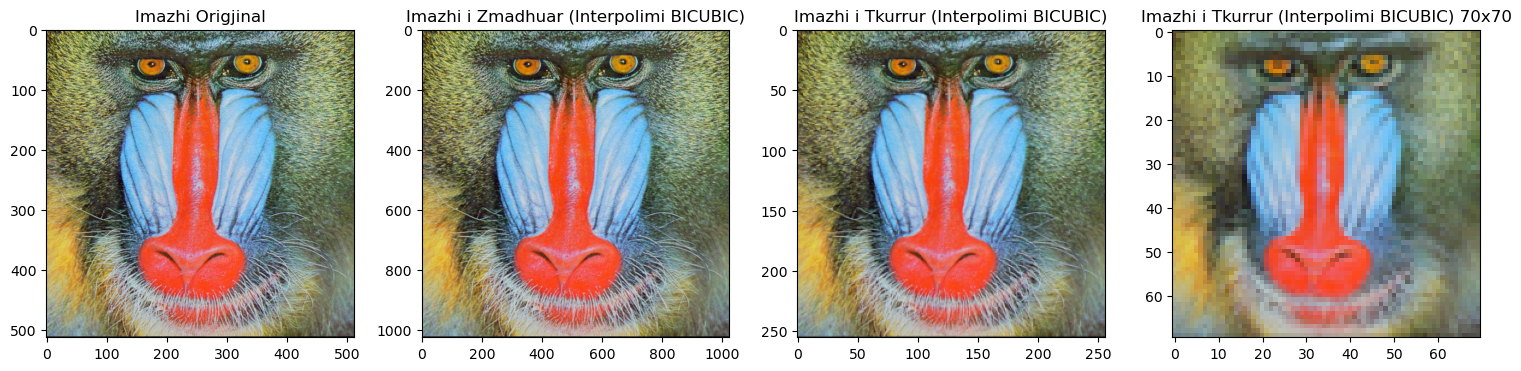

In [15]:
# Zmadhimi i imazhit me interpolim
im_resized_up = im.resize((im.width * 2, im.height * 2), Image.BICUBIC)

# Tkurrja e imazhit me interpolim
im_resized_down = im.resize((im.width // 2, im.height // 2), Image.BICUBIC)

# Tkurrja e imazhit me interpolim
im_resized_70x70 = im.resize((70, 70), Image.BICUBIC)

# Krijojmë figura për të shfaqur imazhet
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Shfaqim imazhin origjinal dhe të zmadhuar dhe të tkurrur
axes[0].imshow(im)
axes[0].set_title('Imazhi Origjinal')

axes[1].imshow(im_resized_up)
axes[1].set_title('Imazhi i Zmadhuar (Interpolimi BICUBIC)')

axes[2].imshow(im_resized_down)
axes[2].set_title('Imazhi i Tkurrur (Interpolimi BICUBIC)')

axes[3].imshow(im_resized_70x70)
axes[3].set_title('Imazhi i Tkurrur (Interpolimi BICUBIC) 70x70')

plt.tight_layout()
plt.show()


[1]  Imazhet jan marre nga: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

<h3 align="center"> &#169; UMT. All rights reserved. <h3/>